# Customer Segmentation Analysis

### Libraries

In [75]:
!pip install scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://vg-s-nexus.dslocal.com/repository/python-main/simple



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\seb21361\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


### Exploratory Data Analyis

In [76]:
df = pd.read_csv("C:/Users/seb21361/Desktop/Mall_Customers.csv")

In [77]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [78]:
df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [79]:
df.rename(columns={'Annual Income (k$)': 'Annual Income'}, inplace=True)

In [80]:
df.rename(columns={'Spending Score (1-100)': 'Spending Score'}, inplace=True)

In [81]:
df.rename(columns={'Genre': 'Gender'}, inplace=True)

In [82]:
df = df.drop('CustomerID', axis=1)

Categoric Variables

In [83]:
df['Gender'].value_counts()

Gender
Female    112
Male       88
Name: count, dtype: int64

Numeric variables

In [84]:
df.describe()

,Age,Annual Income,Spending Score
count,200.000000,200.000000,200.000000
mean,38.850000,60.560000,50.200000
std,13.969007,26.264721,25.823522
min,18.000000,15.000000,1.000000
25%,28.750000,41.500000,34.750000
50%,36.000000,61.500000,50.000000
75%,49.000000,78.000000,73.000000
max,70.000000,137.000000,99.000000


Important notes
- Age ranges between 18 and 70 years old.
- Annual income of the customers range between 15k and 137k. | std = 26
- Mall atributed scores from 1 to 100 to the custoners, based on their spending levels.
- Females > Males

#### 1. Distributions Analysis

In [ ]:
bins = [18, 25, 35, 45, 55, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '56-70']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, include_lowest=True)

In [97]:
bins   = [15, 40, 70, 100, 145]
labels = ['Low', 'Medium', 'High', 'Very High']

df['IncomeGroup'] = pd.cut(df['Annual Income'], bins=bins, labels=labels, include_lowest=True)

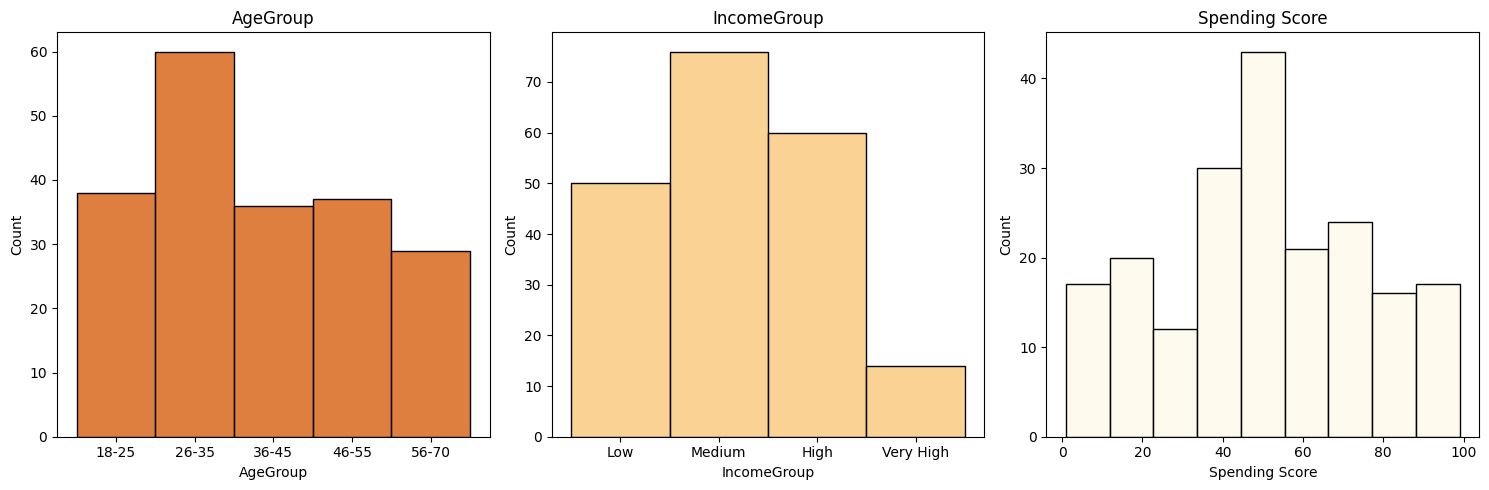

In [98]:
cols = ['AgeGroup', 'IncomeGroup', 'Spending Score']
colors = ["#D35400", "#F8C471", "#FEF9E7"]

fig, axes = plt.subplots(1, len(cols), figsize=(15, 5))

for i, col in enumerate(cols):
    sns.histplot(df[col], ax=axes[i], color=colors[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

Majority of the mall customers are within the 26-35 age group.

##### - Log transformation
- In this case not so effective, best approach could be identifying and removing outliers by boxplots.

<Axes: xlabel='Annual Income', ylabel='Count'>

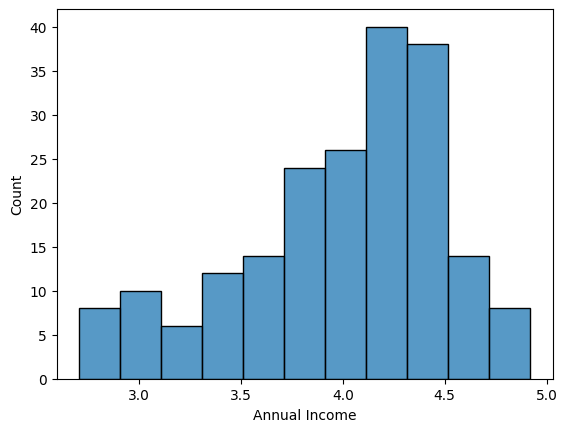

In [87]:
sns.histplot(np.log(df['Annual Income']))

#### 2. Outliers
- No outliers found except for Annual Income.

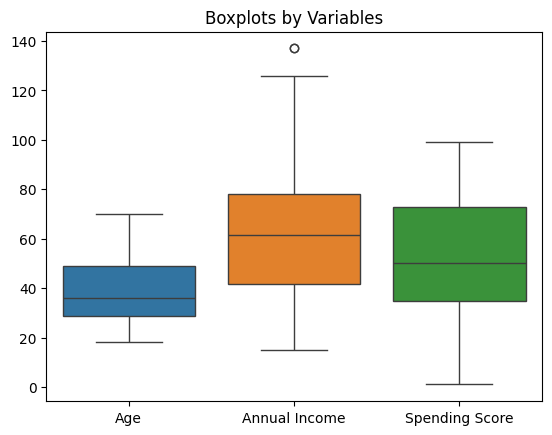

In [88]:
sns.boxplot(df)
plt.title("Boxplots by Variables")
plt.show()

In [99]:
Q1 = df['Annual Income'].quantile(0.25)
Q3 = df['Annual Income'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Annual Income'] < lower) | (df['Annual Income'] > upper)]
outliers

,Gender,Age,Annual Income,Spending Score,AgeGroup,IncomeGroup
198,Male,32,137,18,26-35,Very High
199,Male,30,137,83,26-35,Very High


In [90]:
df_clean = df[(df['Annual Income'] >= lower) & (df['Annual Income'] <= upper)]

In [91]:
df_clean.shape

(198, 5)

In [92]:
df.shape

(200, 5)

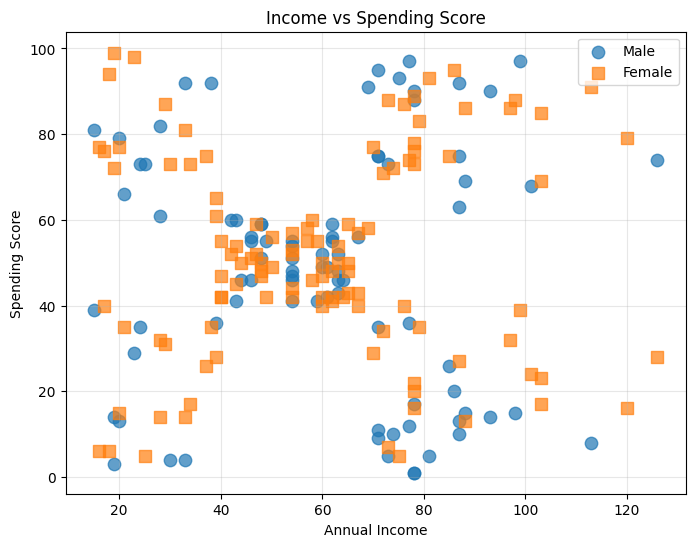

In [101]:
markers = {"Male": "o", "Female": "s"}

plt.figure(figsize=(8,6))

for gender, marker in markers.items():
    subset = df_clean[df_clean['Gender']==gender]
    plt.scatter(subset['Annual Income'],
                subset['Spending Score'],
                label = gender,
                marker = marker,
                s=80,
                alpha = 0.7)
    
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Income vs Spending Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

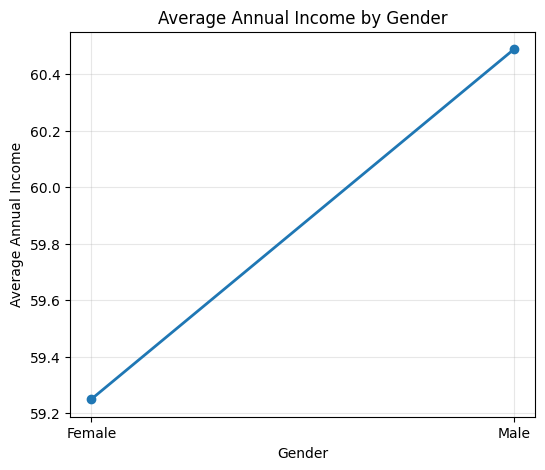

In [95]:
grouped = df_clean.groupby('Gender')['Annual Income'].mean()
plt.figure(figsize=(6,5))
plt.plot(grouped.index, grouped.values, marker='o', linewidth=2)
plt.xlabel('Gender')
plt.ylabel('Average Annual Income')
plt.title('Average Annual Income by Gender')
plt.grid(alpha = 0.3)
plt.show()

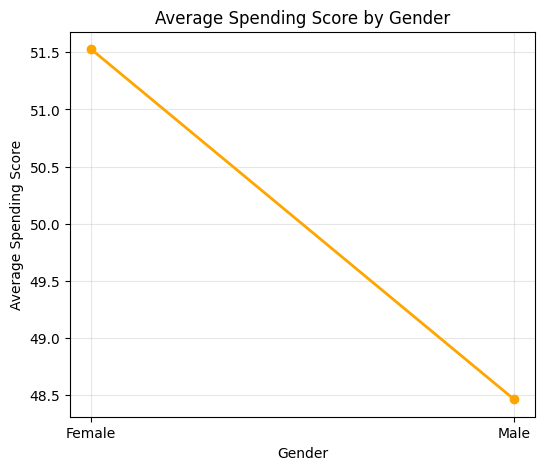

In [96]:
grouped1 = df_clean.groupby('Gender')['Spending Score'].mean()
plt.figure(figsize=(6,5))
plt.plot(grouped1.index, grouped1.values, marker='o', color='orange', linewidth=2)
plt.xlabel('Gender')
plt.ylabel('Average Spending Score')
plt.title('Average Spending Score by Gender')
plt.grid(alpha = 0.3)
plt.show()